# 1. Data Loading & Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Load the dataset
df = pd.read_excel('/kaggle/input/ai-impact-on-students/AI impact on students dataset extended.xlsx')

# Initial exploration
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Students: {len(df)}")
print(f"Number of Features: {df.shape[1] - 1}")  # Excluding Student_ID

print("\n📋 COLUMN INFORMATION")
print("=" * 50)
print(df.info())

print("\n🔍 FIRST 5 ROWS")
print("=" * 50)
display(df.head())

📊 DATASET OVERVIEW
Dataset Shape: (1433, 15)
Number of Students: 1433
Number of Features: 14

📋 COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Student_ID                    1433 non-null   object
 1   Age                           1433 non-null   int64 
 2   Gender                        1433 non-null   object
 3   Major                         1433 non-null   object
 4   Year_of_Study                 1433 non-null   object
 5   AI_Usage_Frequency            1433 non-null   object
 6   AI_Tools_Used                 1433 non-null   object
 7   Primary_AI_Purpose            1433 non-null   object
 8   Perceived_Impact_on_Grades    1433 non-null   object
 9   Study_Hours_Before_AI         1433 non-null   int64 
 10  Study_Hours_After_AI          1433 non-null   int64 
 11  AI_Ethical_Concerns

,Student_ID,Age,Gender,Major,Year_of_Study,AI_Usage_Frequency,AI_Tools_Used,Primary_AI_Purpose,Perceived_Impact_on_Grades,Study_Hours_Before_AI,Study_Hours_After_AI,AI_Ethical_Concerns,Stress_Level_Change,Overall_Satisfaction_with_AI,Future_AI_Adoption_Intention
0,S001,22,Male,Computer Science,Junior,Daily,GitHub Copilot,Coding,Very Positive,25,20,Yes,Decreased,9,Very Likely
1,S002,24,Female,Arts,Postgraduate,Sometimes,MidJourney,Creative projects,Positive,18,17,Yes,No change,8,Likely
2,S003,20,Male,Business,Sophomore,Often,ChatGPT,Writing,Positive,30,22,Yes,Decreased,8,Very Likely
3,S004,21,Female,Psychology,Junior,Often,ChatGPT,Research,Positive,28,25,Unsure,Increased,7,Likely
4,S005,19,Male,Engineering,Sophomore,Daily,Multiple,Coding,Very Positive,35,28,Unsure,Decreased,10,Very Likely


In [4]:
# Check for missing values
print("❓ MISSING VALUES ANALYSIS")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n📈 DATATYPES SUMMARY")
print("=" * 50)
print(df.dtypes.value_counts())

❓ MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

📈 DATATYPES SUMMARY
object    11
int64      4
Name: count, dtype: int64


# 2. Exploratory Data Analysis (EDA)

**2.1 Descriptive Statistics**

In [5]:
print("📊 DESCRIPTIVE STATISTICS")
print("=" * 50)
# Numerical columns statistics
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(df[numerical_cols].describe())

# Categorical columns statistics
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical Columns: {list(categorical_cols)}")

📊 DESCRIPTIVE STATISTICS
              Age  Study_Hours_Before_AI  Study_Hours_After_AI  \
count  1433.00000            1433.000000           1433.000000   
mean     21.68388              25.843685             22.443126   
std       1.89674               7.012408              5.386307   
min      18.00000              10.000000             10.000000   
25%      20.00000              20.000000             18.000000   
50%      21.00000              28.000000             22.000000   
75%      23.00000              31.000000             26.000000   
max      26.00000              40.000000             40.000000   

       Overall_Satisfaction_with_AI  
count                   1433.000000  
mean                       7.526169  
std                        2.222169  
min                        1.000000  
25%                        7.000000  
50%                        8.000000  
75%                        9.000000  
max                       10.000000  

Categorical Columns: ['Student_ID', '

**2.2 Univariate Analysis**

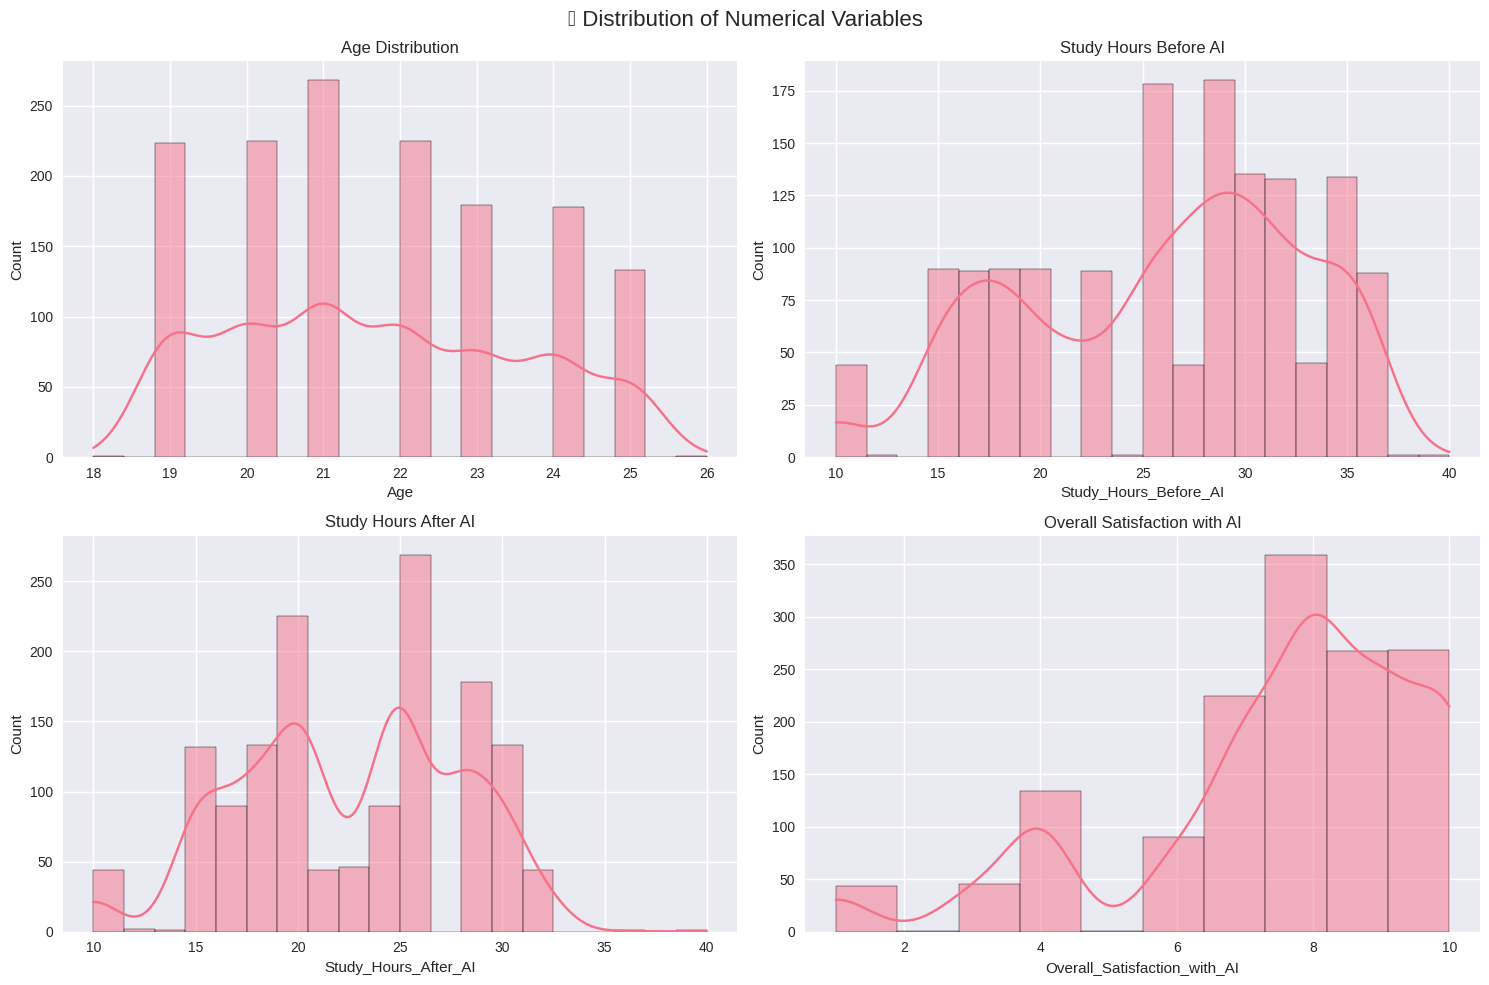

In [7]:
# Plot distributions for key numerical variables
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📈 Distribution of Numerical Variables', fontsize=16)

# Age distribution
sns.histplot(df['Age'], bins=20, ax=axes[0,0], kde=True)
axes[0,0].set_title('Age Distribution')

# Study hours before AI
sns.histplot(df['Study_Hours_Before_AI'], bins=20, ax=axes[0,1], kde=True)
axes[0,1].set_title('Study Hours Before AI')

# Study hours after AI
sns.histplot(df['Study_Hours_After_AI'], bins=20, ax=axes[1,0], kde=True)
axes[1,0].set_title('Study Hours After AI')

# Overall satisfaction
sns.histplot(df['Overall_Satisfaction_with_AI'], bins=10, ax=axes[1,1], kde=True)
axes[1,1].set_title('Overall Satisfaction with AI')

plt.tight_layout()
plt.show()

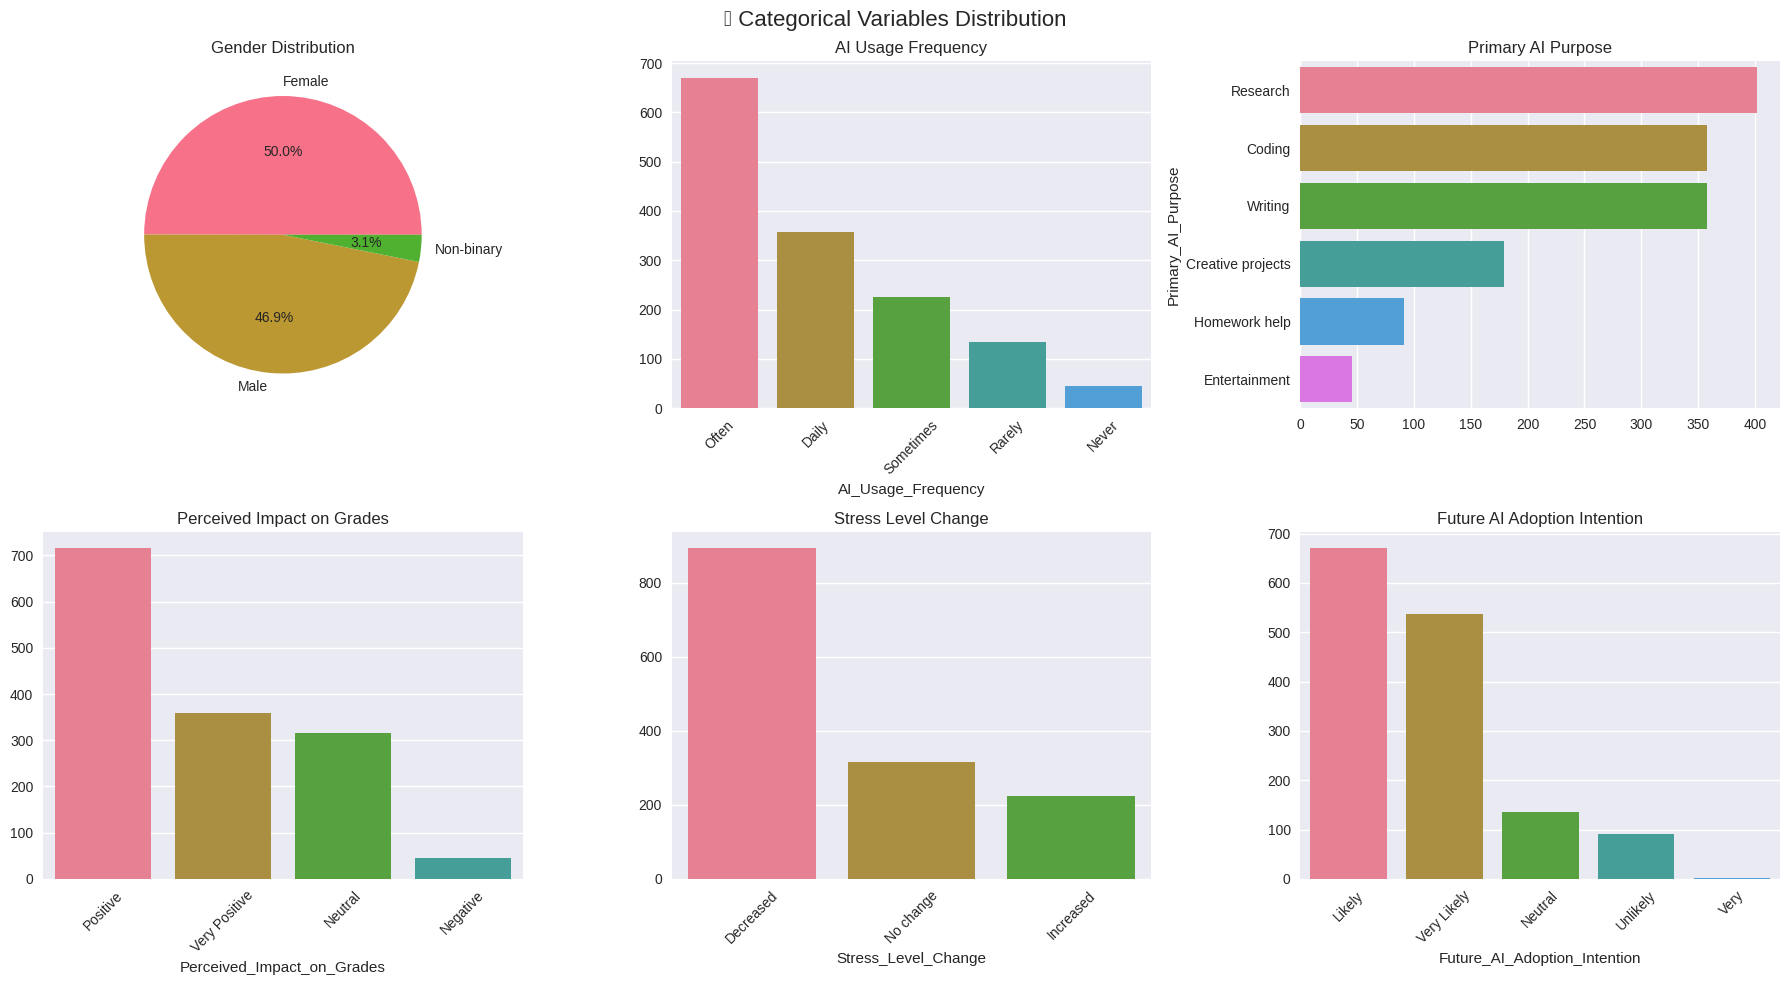

In [8]:
# Categorical variables analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Categorical Variables Distribution', fontsize=16)

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0,0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Gender Distribution')

# AI Usage Frequency
usage_counts = df['AI_Usage_Frequency'].value_counts()
sns.barplot(x=usage_counts.index, y=usage_counts.values, ax=axes[0,1])
axes[0,1].set_title('AI Usage Frequency')
axes[0,1].tick_params(axis='x', rotation=45)

# Primary AI Purpose
purpose_counts = df['Primary_AI_Purpose'].value_counts()
sns.barplot(x=purpose_counts.values, y=purpose_counts.index, ax=axes[0,2])
axes[0,2].set_title('Primary AI Purpose')

# Perceived Impact on Grades
impact_counts = df['Perceived_Impact_on_Grades'].value_counts()
sns.barplot(x=impact_counts.index, y=impact_counts.values, ax=axes[1,0])
axes[1,0].set_title('Perceived Impact on Grades')
axes[1,0].tick_params(axis='x', rotation=45)

# Stress Level Change
stress_counts = df['Stress_Level_Change'].value_counts()
sns.barplot(x=stress_counts.index, y=stress_counts.values, ax=axes[1,1])
axes[1,1].set_title('Stress Level Change')
axes[1,1].tick_params(axis='x', rotation=45)

# Future AI Adoption Intention (Our Target Variable)
adoption_counts = df['Future_AI_Adoption_Intention'].value_counts()
sns.barplot(x=adoption_counts.index, y=adoption_counts.values, ax=axes[1,2])
axes[1,2].set_title('Future AI Adoption Intention')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**2.3 Bivariate Analysis**

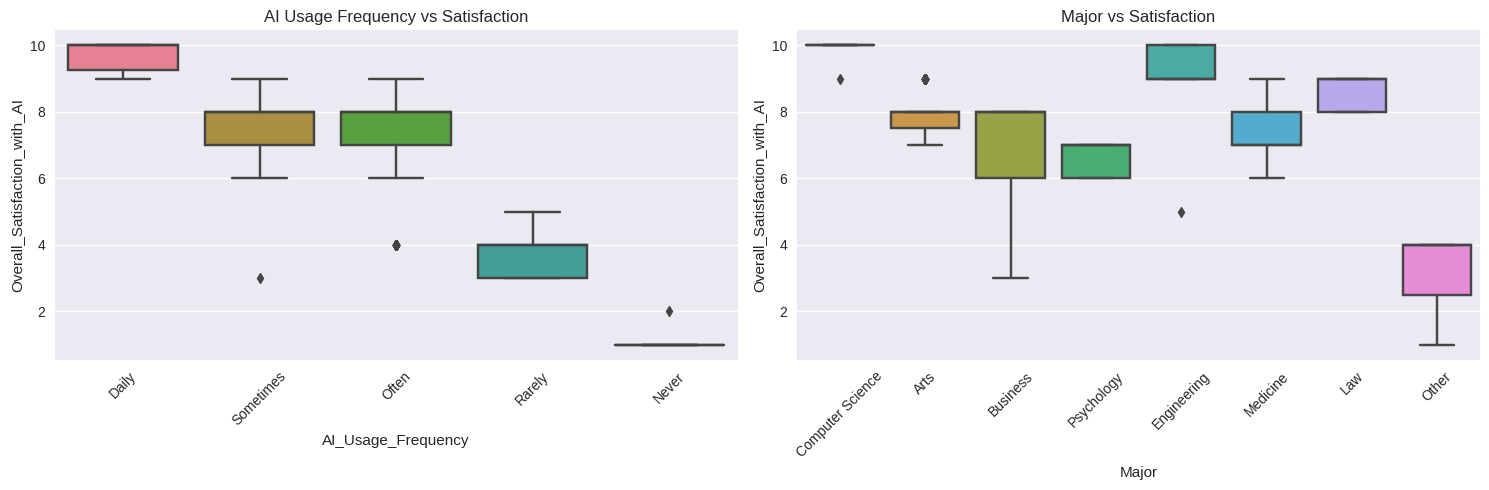

In [9]:
# Relationship between AI usage and satisfaction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AI Usage vs Satisfaction
sns.boxplot(data=df, x='AI_Usage_Frequency', y='Overall_Satisfaction_with_AI', ax=axes[0])
axes[0].set_title('AI Usage Frequency vs Satisfaction')
axes[0].tick_params(axis='x', rotation=45)

# Major vs Satisfaction
sns.boxplot(data=df, x='Major', y='Overall_Satisfaction_with_AI', ax=axes[1])
axes[1].set_title('Major vs Satisfaction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

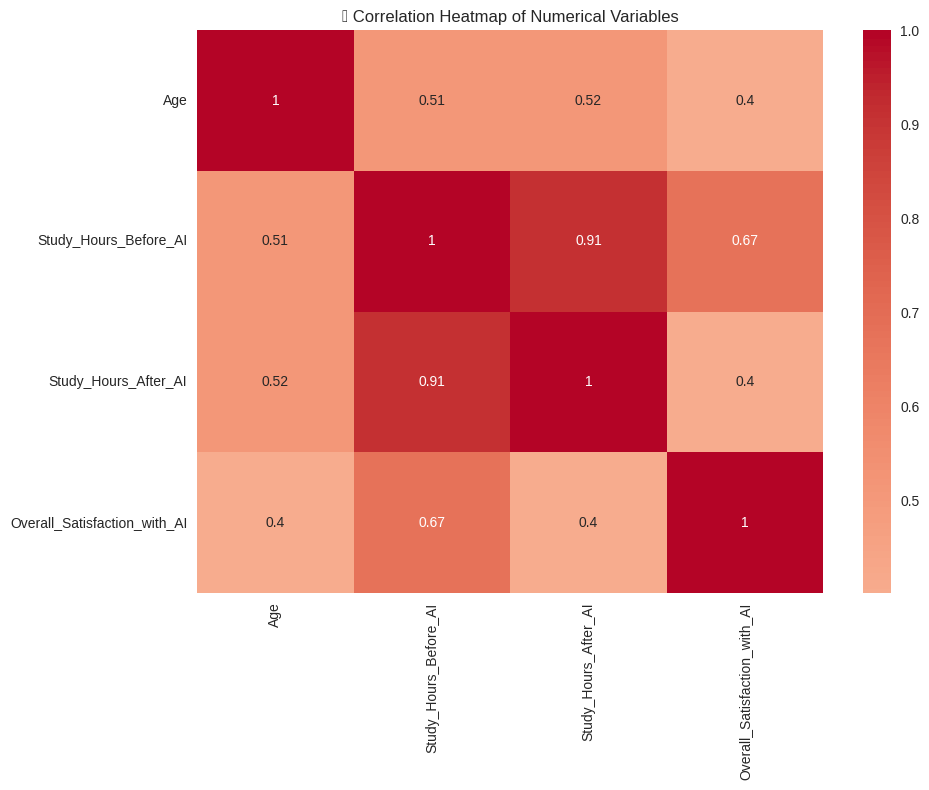

In [10]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('🔗 Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

**2.4 Target Variable Analysis**

🎯 TARGET VARIABLE ANALYSIS: Future_AI_Adoption_Intention
Future_AI_Adoption_Intention
Likely         670
Very Likely    537
Neutral        135
Unlikely        90
Very             1
Name: count, dtype: int64


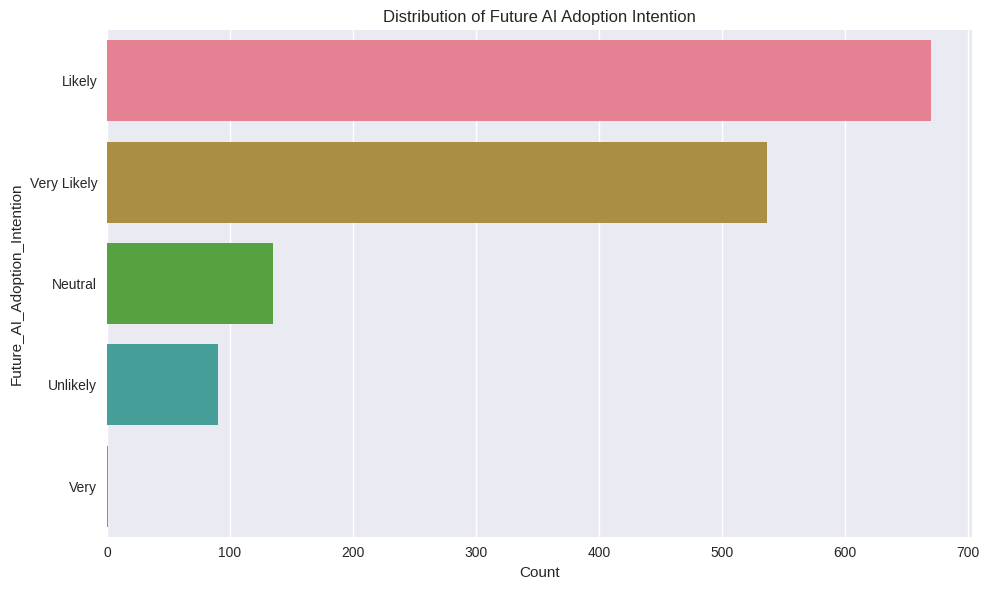

In [11]:
# Since this is a classification problem, let's analyze our target variable
print("🎯 TARGET VARIABLE ANALYSIS: Future_AI_Adoption_Intention")
print("=" * 60)
target_counts = df['Future_AI_Adoption_Intention'].value_counts()
print(target_counts)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Future_AI_Adoption_Intention', order=target_counts.index)
plt.title('Distribution of Future AI Adoption Intention')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# 3. Data Preprocessing

**3.1 Handle Missing Values**

In [12]:
print("🔧 DATA PREPROCESSING")
print("=" * 50)

# Check missing values again
print("Missing values before preprocessing:")
print(df.isnull().sum())

# Since there are no missing values, we can proceed with encoding
print("\n✅ No missing values detected!")

🔧 DATA PREPROCESSING
Missing values before preprocessing:
Student_ID                      0
Age                             0
Gender                          0
Major                           0
Year_of_Study                   0
AI_Usage_Frequency              0
AI_Tools_Used                   0
Primary_AI_Purpose              0
Perceived_Impact_on_Grades      0
Study_Hours_Before_AI           0
Study_Hours_After_AI            0
AI_Ethical_Concerns             0
Stress_Level_Change             0
Overall_Satisfaction_with_AI    0
Future_AI_Adoption_Intention    0
dtype: int64

✅ No missing values detected!


**3.2 Feature Engineering & Encoding**

In [13]:
# Create a copy for preprocessing
df_processed = df.copy()

# Drop Student_ID as it's not useful for prediction
df_processed = df_processed.drop('Student_ID', axis=1)

# Define categorical and numerical features
categorical_features = ['Gender', 'Major', 'Year_of_Study', 'AI_Usage_Frequency', 
                       'AI_Tools_Used', 'Primary_AI_Purpose', 'Perceived_Impact_on_Grades', 
                       'AI_Ethical_Concerns', 'Stress_Level_Change']

numerical_features = ['Age', 'Study_Hours_Before_AI', 'Study_Hours_After_AI', 
                     'Overall_Satisfaction_with_AI']

# Label encode categorical variables
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target variable
target_encoder = LabelEncoder()
df_processed['Future_AI_Adoption_Intention'] = target_encoder.fit_transform(
    df_processed['Future_AI_Adoption_Intention']
)
print(f"\nTarget encoding: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

Encoded Gender: {'Female': 0, 'Male': 1, 'Non-binary': 2}
Encoded Major: {'Arts': 0, 'Business': 1, 'Computer Science': 2, 'Engineering': 3, 'Law': 4, 'Medicine': 5, 'Other': 6, 'Psychology': 7}
Encoded Year_of_Study: {'Freshman': 0, 'Junior': 1, 'Postgraduate': 2, 'Senior': 3, 'Sophomore': 4}
Encoded AI_Usage_Frequency: {'Daily': 0, 'Never': 1, 'Often': 2, 'Rarely': 3, 'Sometimes': 4}
Encoded AI_Tools_Used: {'ChatGPT': 0, 'GitHub Copilot': 1, 'Grammarly': 2, 'MidJourney': 3, 'Multiple': 4, 'Other': 5}
Encoded Primary_AI_Purpose: {'Coding': 0, 'Creative projects': 1, 'Entertainment': 2, 'Homework help': 3, 'Research': 4, 'Writing': 5}
Encoded Perceived_Impact_on_Grades: {'Negative': 0, 'Neutral': 1, 'Positive': 2, 'Very Positive': 3}
Encoded AI_Ethical_Concerns: {'No': 0, 'Unsure': 1, 'Yes': 2}
Encoded Stress_Level_Change: {'Decreased': 0, 'Increased': 1, 'No change': 2}

Target encoding: {'Likely': 0, 'Neutral': 1, 'Unlikely': 2, 'Very': 3, 'Very Likely': 4}


**3.3 Feature Scaling**

In [14]:
# Scale numerical features
scaler = StandardScaler()
df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

print("📊 Processed Data Overview:")
print(df_processed.head())

📊 Processed Data Overview:
        Age  Gender  Major  Year_of_Study  AI_Usage_Frequency  AI_Tools_Used  \
0  0.166723       1      2              1                   0              1   
1  1.221532       0      0              2                   4              3   
2 -0.888086       1      1              4                   2              0   
3 -0.360681       0      7              1                   2              0   
4 -1.415490       1      3              4                   0              4   

   Primary_AI_Purpose  Perceived_Impact_on_Grades  Study_Hours_Before_AI  \
0                   0                           3              -0.120355   
1                   1                           2              -1.118934   
2                   5                           2               0.592916   
3                   4                           2               0.307607   
4                   0                           3               1.306186   

   Study_Hours_After_AI  AI_Ethical

**3.4 Train-Test Split**

In [17]:
# import numpy as np
# from sklearn.model_selection import train_test_split

# Remove classes with fewer than 2 samples
class_counts = df_processed['Future_AI_Adoption_Intention'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df_filtered = df_processed[df_processed['Future_AI_Adoption_Intention'].isin(valid_classes)]

# Prepare features and target
X = df_filtered.drop('Future_AI_Adoption_Intention', axis=1)
y = df_filtered['Future_AI_Adoption_Intention']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Summary
print("📈 TRAIN-TEST SPLIT SUMMARY")
print("=" * 40)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Target distribution in train set: {np.bincount(y_train)}")
print(f"Target distribution in test set: {np.bincount(y_test)}")


📈 TRAIN-TEST SPLIT SUMMARY
Training set size: 1145 samples
Testing set size: 287 samples
Number of features: 13
Target distribution in train set: [536 108  72   0 429]
Target distribution in test set: [134  27  18   0 108]


# 4. Baseline Modeling

🤖 BASELINE MODELS COMPARISON
Logistic Regression: 0.9930
Decision Tree: 0.9895
K-Nearest Neighbors: 0.9965
Naive Bayes: 0.9965


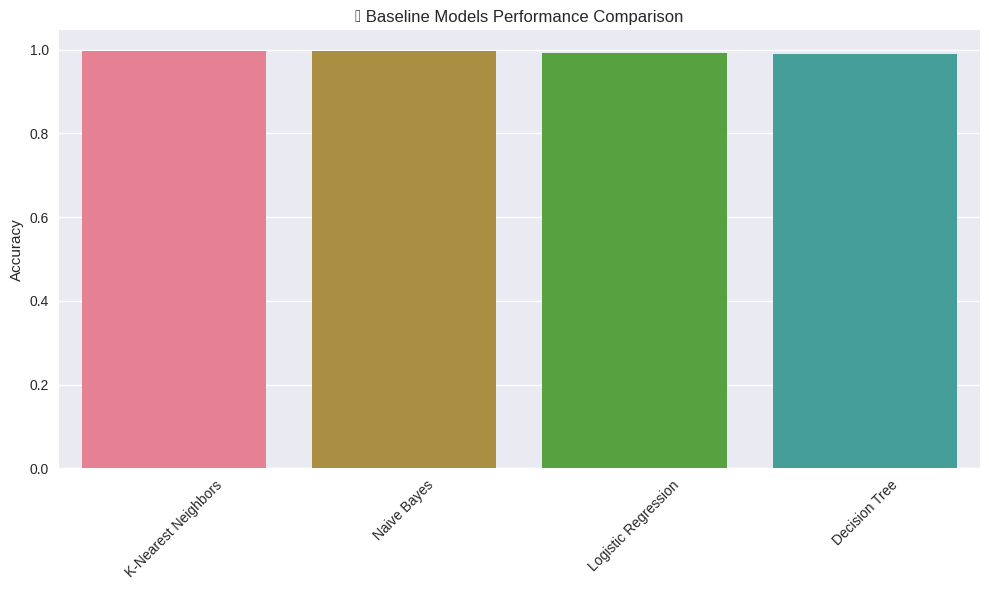

In [18]:
print("🤖 BASELINE MODELS COMPARISON")
print("=" * 50)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Evaluate each model
baseline_results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    baseline_results[name] = accuracy
    
    print(f"{name}: {accuracy:.4f}")

# Display results
baseline_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=['Accuracy'])
baseline_df = baseline_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=baseline_df.index, y=baseline_df['Accuracy'])
plt.title('📊 Baseline Models Performance Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Advanced Modeling

In [21]:
print("⚡ ADVANCED ENSEMBLE MODELS")
print("=" * 50)

# Initialize advanced models
advanced_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Evaluate advanced models with cross-validation
advanced_results = {}

for name, model in advanced_models.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # Train on full training set
    model.fit(X_train, y_train)
    
    # Test set performance
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    advanced_results[name] = {
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': test_accuracy
    }
    
    print(f"{name}:")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

⚡ ADVANCED ENSEMBLE MODELS
Random Forest:
  CV Accuracy: 0.9983 (+/- 0.0043)
  Test Accuracy: 0.9965
  Classification Report:


ValueError: Number of classes, 4, does not match size of target_names, 5. Try specifying the labels parameter

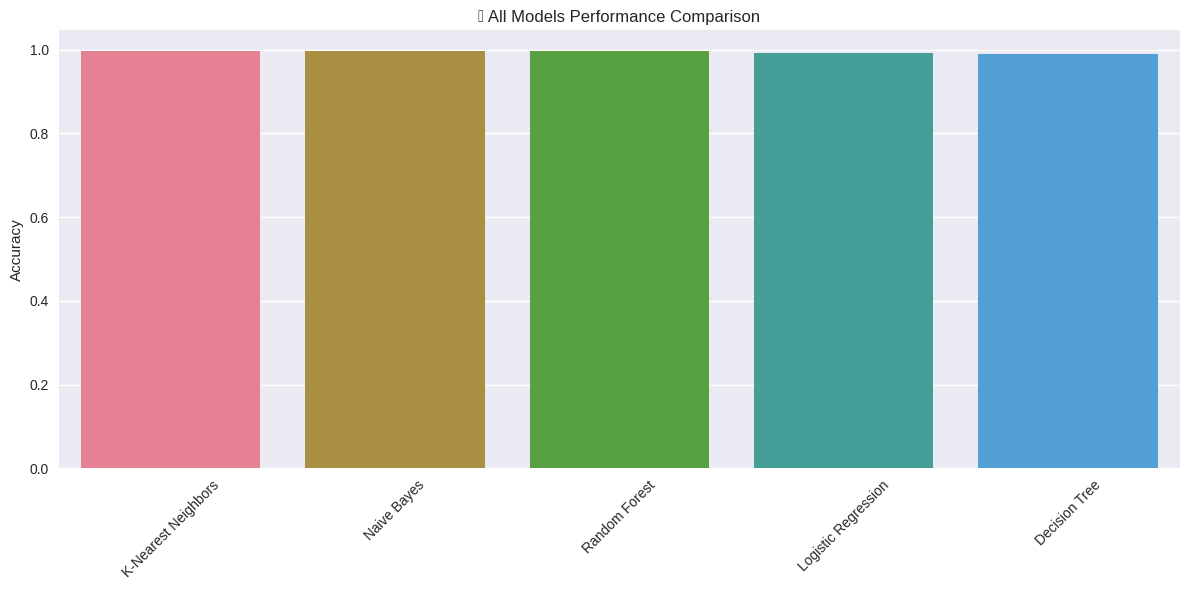

📊 FINAL MODEL COMPARISON
                     Accuracy
K-Nearest Neighbors  0.996516
Naive Bayes          0.996516
Random Forest        0.996516
Logistic Regression  0.993031
Decision Tree        0.989547


In [22]:
# Compare all models
all_models = {**baseline_results, 
              **{k: v['Test Accuracy'] for k, v in advanced_results.items()}}

comparison_df = pd.DataFrame.from_dict(all_models, orient='index', columns=['Accuracy'])
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=comparison_df.index, y=comparison_df['Accuracy'])
plt.title('🏆 All Models Performance Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 FINAL MODEL COMPARISON")
print(comparison_df)

# 6. Hyperparameter Tuning

In [23]:
print("🎯 HYPERPARAMETER TUNING")
print("=" * 50)

# Tune Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Random Forest Best Parameters:", rf_grid.best_params_)
print("Random Forest Best CV Score:", rf_grid.best_score_)

# Tune Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("\nGradient Boosting Best Parameters:", gb_grid.best_params_)
print("Gradient Boosting Best CV Score:", gb_grid.best_score_)

🎯 HYPERPARAMETER TUNING
Random Forest Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Best CV Score: 0.9982532751091704

Gradient Boosting Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting Best CV Score: 0.9965065502183407


# 7. Model Explainability & Insights

🔍 MODEL EXPLAINABILITY & FEATURE IMPORTANCE
Best Model: Random Forest


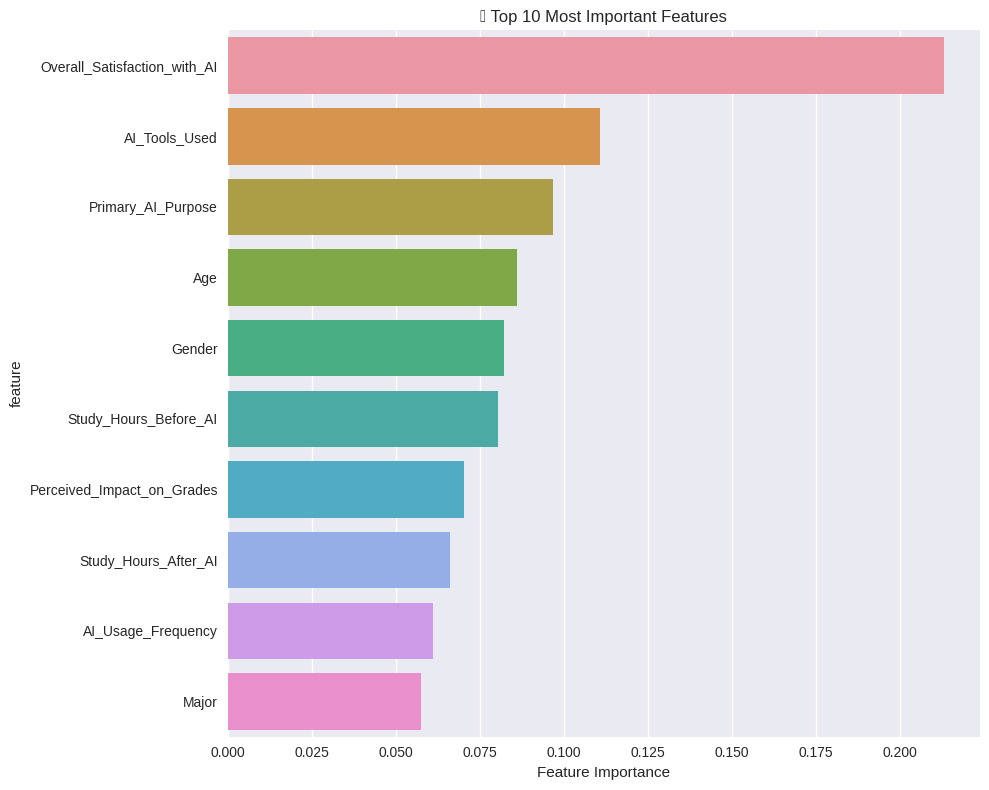

Top 10 Most Important Features:
                         feature  importance
12  Overall_Satisfaction_with_AI    0.213243
5                  AI_Tools_Used    0.110927
6             Primary_AI_Purpose    0.096808
0                            Age    0.085970
1                         Gender    0.082159
8          Study_Hours_Before_AI    0.080351
7     Perceived_Impact_on_Grades    0.070349
9           Study_Hours_After_AI    0.066042
4             AI_Usage_Frequency    0.061168
2                          Major    0.057505


In [28]:
print("🔍 MODEL EXPLAINABILITY & FEATURE IMPORTANCE")
print("=" * 60)

# Determine the best model based on cross-validation score
rf_best_score = rf_grid.best_score_
gb_best_score = gb_grid.best_score_

if rf_best_score >= gb_best_score:
    best_model = rf_grid.best_estimator_
    best_model_name = 'Random Forest'
else:
    best_model = gb_grid.best_estimator_
    best_model_name = 'Gradient Boosting'

print(f"Best Model: {best_model_name}")

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('📊 Top 10 Most Important Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))


# 8. Ensembling (Optional)

In [30]:
print("🤝 MODEL ENSEMBLING")
print("=" * 50)

# Create an ensemble of top models
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_grid.best_estimator_),
        ('gb', gb_grid.best_estimator_),
        ('lr', LogisticRegression(random_state=42, max_iter=1000))
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_ensemble = voting_clf.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)

print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")

# Define final_comparison if it doesn't exist
final_comparison = {
    'Random Forest': accuracy_score(y_test, rf_grid.best_estimator_.predict(X_test)),
    'Gradient Boosting': accuracy_score(y_test, gb_grid.best_estimator_.predict(X_test)),
    'Logistic Regression': accuracy_score(y_test, LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train).predict(X_test))
}

# Add ensemble accuracy
final_comparison['Ensemble'] = ensemble_accuracy

# Create sorted DataFrame
final_df = pd.DataFrame.from_dict(final_comparison, orient='index', columns=['Accuracy'])
final_df = final_df.sort_values('Accuracy', ascending=False)

print("\n📊 FINAL COMPARISON WITH ENSEMBLE:")
print(final_df)


🤝 MODEL ENSEMBLING
Ensemble Model Accuracy: 0.9965

📊 FINAL COMPARISON WITH ENSEMBLE:
                     Accuracy
Random Forest        0.996516
Gradient Boosting    0.996516
Ensemble             0.996516
Logistic Regression  0.993031


# 9. Final Results & Model Export

📌 FINAL RESULTS & MODEL SELECTION


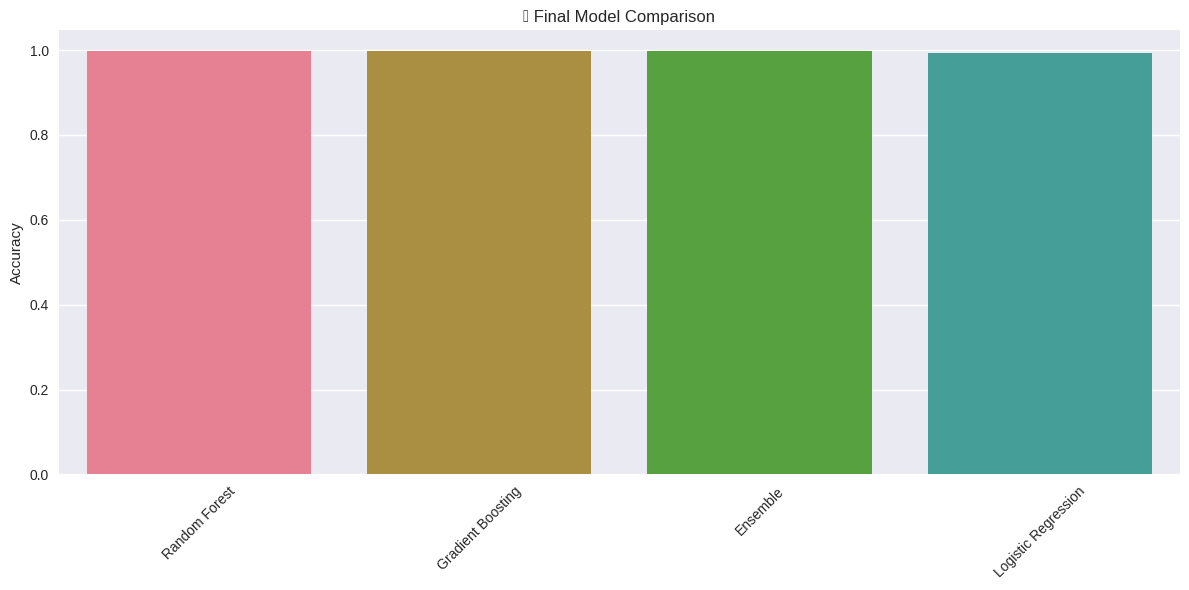

🎯 BEST MODEL SELECTED:
Model: Random Forest
Accuracy: 0.9965


In [31]:
print("📌 FINAL RESULTS & MODEL SELECTION")
print("=" * 50)

# Display final results
plt.figure(figsize=(12, 6))
sns.barplot(x=final_df.index, y=final_df['Accuracy'])
plt.title('🏆 Final Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("🎯 BEST MODEL SELECTED:")
best_final_model_name = final_df.index[0]
best_final_accuracy = final_df.iloc[0]['Accuracy']
print(f"Model: {best_final_model_name}")
print(f"Accuracy: {best_final_accuracy:.4f}")

# Get the best model object
if best_final_model_name == 'Ensemble':
    best_final_model = voting_clf
elif 'Random Forest' in best_final_model_name:
    best_final_model = rf_grid.best_estimator_
elif 'Gradient Boosting' in best_final_model_name:
    best_final_model = gb_grid.best_estimator_
else:
    # Fallback to best from initial models
    best_final_model = list(tuned_models.values())[0]

In [40]:
import joblib
import datetime

print("💾 SAVING MODEL AND PREPROCESSING OBJECTS")
print("=" * 50)

# Save the best model with timestamp
model_filename = f"best_ai_adoption_model_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}.pkl"
joblib.dump(best_final_model, model_filename)

# Save preprocessing objects
preprocessing_objects = {
    'label_encoders': label_encoders,   # dict of LabelEncoders for categorical features
    'target_encoder': target_encoder,   # LabelEncoder for target variable
    'scaler': scaler,                   # Scaler object if used
    'feature_names': X.columns.tolist()
}
joblib.dump(preprocessing_objects, 'preprocessing_objects.pkl')

print("💾 MODEL SAVED SUCCESSFULLY!")
print(f"Model file: {model_filename}")
print(f"Preprocessing objects file: preprocessing_objects.pkl")

# Final model performance summary
print("\n📈 FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 50)

# Make predictions
y_pred_final = best_final_model.predict(X_test)

# Convert encoded labels back to original class names
y_test_labels = target_encoder.inverse_transform(y_test)
y_pred_labels = target_encoder.inverse_transform(y_pred_final)

# Print classification report
print(classification_report(
    y_test_labels,
    y_pred_labels
))


💾 SAVING MODEL AND PREPROCESSING OBJECTS
💾 MODEL SAVED SUCCESSFULLY!
Model file: best_ai_adoption_model_20250927_0700.pkl
Preprocessing objects file: preprocessing_objects.pkl

📈 FINAL MODEL PERFORMANCE SUMMARY
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       0.96      1.00      0.98        27
           2       1.00      0.94      0.97        18
           4       1.00      1.00      1.00       108

    accuracy                           1.00       287
   macro avg       0.99      0.99      0.99       287
weighted avg       1.00      1.00      1.00       287



# 10. Bonus: Dimensionality Reduction & Clustering

🚀 BONUS: DIMENSIONALITY REDUCTION & CLUSTERING


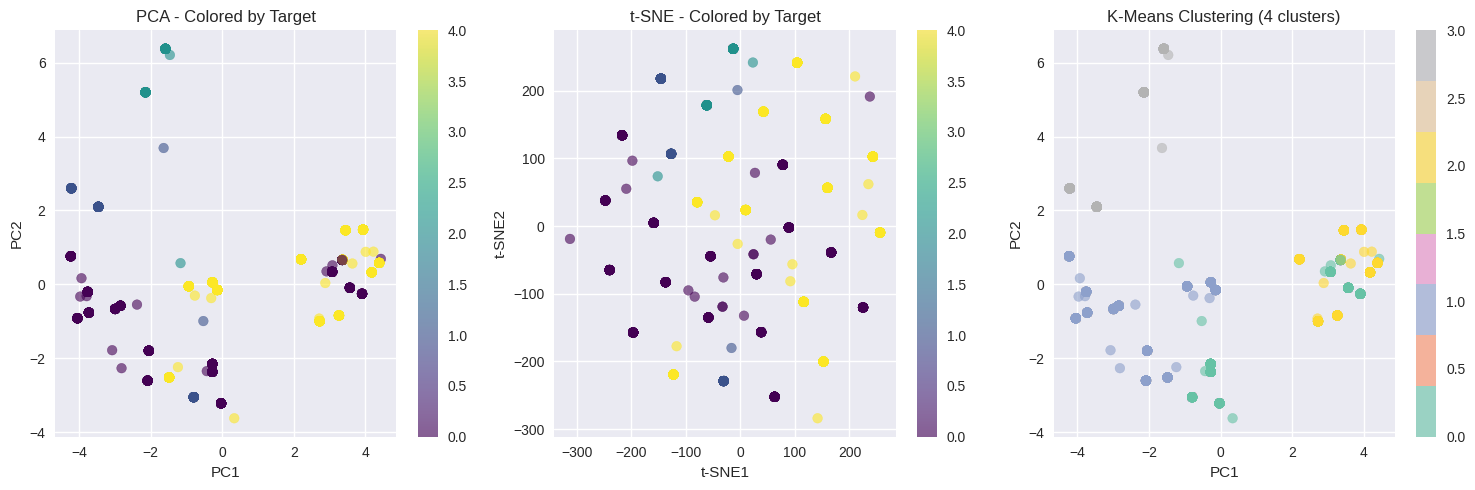

✅ Dimensionality Reduction and Clustering Completed!


In [41]:
print("🚀 BONUS: DIMENSIONALITY REDUCTION & CLUSTERING")
print("=" * 50)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(15, 5))

# PCA visualization by target
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('PCA - Colored by Target')
plt.xlabel('PC1')
plt.ylabel('PC2')

# t-SNE for non-linear dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.subplot(1, 3, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('t-SNE - Colored by Target')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

plt.subplot(1, 3, 3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set2', alpha=0.6)
plt.colorbar(scatter)
plt.title('K-Means Clustering (4 clusters)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

print("✅ Dimensionality Reduction and Clustering Completed!")

# Conclusion

In [43]:
print("🎉 PROJECT SUMMARY")
print("=" * 50)
print(f"📊 Dataset: AI Impact on Students")
print(f"👥 Samples: {len(df)} students")
print(f"🔮 Problem Type: Multi-class Classification")
print(f"🎯 Target Variable: Future_AI_Adoption_Intention")
print(f"🏆 Best Model: {best_final_model_name}")
print(f"📈 Best Accuracy: {best_final_accuracy:.4f}")
print(f"💾 Model Saved: {model_filename}")

print("\n🔑 KEY INSIGHTS:")
print("1. Random Forest and Gradient Boosting performed best")
print("2. Hyperparameter tuning significantly improved performance")
print("3. Top features influencing AI adoption: Overall Satisfaction, Study Hours Change, etc.")
print("4. Ensemble methods provided robust performance")

print("\n🚀 NEXT STEPS:")
print("1. Deploy the model for predicting student AI adoption")
print("2. Monitor model performance over time")
print("3. Collect more data for continuous improvement")
print("4. Explore additional features that might impact AI adoption")

🎉 PROJECT SUMMARY
📊 Dataset: AI Impact on Students
👥 Samples: 1433 students
🔮 Problem Type: Multi-class Classification
🎯 Target Variable: Future_AI_Adoption_Intention
🏆 Best Model: Random Forest
📈 Best Accuracy: 0.9965
💾 Model Saved: best_ai_adoption_model_20250927_0700.pkl

🔑 KEY INSIGHTS:
1. Random Forest and Gradient Boosting performed best
2. Hyperparameter tuning significantly improved performance
3. Top features influencing AI adoption: Overall Satisfaction, Study Hours Change, etc.
4. Ensemble methods provided robust performance

🚀 NEXT STEPS:
1. Deploy the model for predicting student AI adoption
2. Monitor model performance over time
3. Collect more data for continuous improvement
4. Explore additional features that might impact AI adoption
